# Fake News Detection




## Objective


The objective of this assignment is to develop a Semantic Classification model. You will be using Word2Vec method to extract the semantic relations from the text and develop a basic understanding of how to train supervised models to categorise text based on its meaning, rather than just syntax. You will explore how this technique is used in situations where understanding textual meaning plays a critical role in making accurate and efficient decisions.


## Business Objective

The spread of fake news has become a significant challenge in today’s digital world. With the massive volume of news articles published daily, it’s becoming harder to distinguish between credible and misleading information. This creates a need for systems that can automatically classify news articles as true or fake, helping to reduce misinformation and protect public trust.


In this assignment, you will develop a Semantic Classification model that uses the Word2Vec method to detect recurring patterns and themes in news articles. Using supervised learning models, the goal is to build a system that classifies news articles as either fake or true.


<h2> Pipelines that needs to be performed </h2>

You need to perform the following tasks to complete the assignment:

<ol type="1">

  <li> Data Preparation
  <li> Text Preprocessing
  <li> Train Validation Split
  <li> EDA on Training Data
  <li> EDA on Validation Data [Optional]
  <li> Feature Extraction
  <li> Model Training and Evaluation

</ol>

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Dictionary


For this assignment, you will work with two datasets, `True.csv` and `Fake.csv`.
Both datasets contain three columns:
<ul>
  <li> title of the news article
  <li> text of the news article
  <li> date of article publication
</ul>

`True.csv` dataset includes 21,417 true news, while the `Fake.csv` dataset comprises 23,502 fake news.

## Installing required Libraries

In [13]:
!pip install --upgrade numpy==1.26.4
!pip install --upgrade pandas==2.2.2
!pip install --upgrade nltk==3.9.1
!pip install --upgrade spacy==3.7.5
!pip install --upgrade scipy==1.12
!pip install --upgrade pydantic==2.10.5
!pip install wordcloud==1.9.4
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 8.1 MB/s eta 0:00:00a 0:00:01m
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## Importing the necessary libraries

In [15]:
import sys
!"{sys.executable}" -m pip install --upgrade pip
!"{sys.executable}" -m pip install nltk

In [16]:
import sys
print(sys.executable)

/opt/anaconda3/envs/mlcourse/bin/python


In [17]:
import nltk
print("NLTK OK:", nltk.__version__)

NLTK OK: 3.9.2


In [18]:
import sys
!"{sys.executable}" -m pip install plotly

In [19]:
# Import essential libraries for data manipulation and analysis
import numpy as np  # For numerical operations and arrays
import pandas as pd  # For working with dataframes and structured data
import re  # For regular expression operations (text processing)
import nltk  # Natural Language Toolkit for text processing
import spacy  # For advanced NLP tasks
import string  # For handling string-related operations

# Optional: Uncomment the line below to enable GPU support for spaCy (if you have a compatible GPU)
#spacy.require_gpu()

# Load the spaCy small English language model
nlp = spacy.load("en_core_web_sm")

# For data visualization
import seaborn as sns  # Data visualization library for statistical graphics
import matplotlib.pyplot as plt  # Matplotlib for creating static plots
# Configure Matplotlib to display plots inline in Jupyter Notebook
%matplotlib inline

# Suppress unnecessary warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# For interactive plots
from plotly.offline import plot  # Enables offline plotting with Plotly
import plotly.graph_objects as go  # For creating customizable Plotly plots
import plotly.express as px  # A high-level interface for Plotly

# For preprocessing and feature extraction in machine learning
from sklearn.feature_extraction.text import (  # Methods for text vectorization
    CountVectorizer,  # Converts text into a bag-of-words model
)

# Import accuracy, precision, recall, f_score from sklearn to predict train accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Pretty printing for better readability of output
from pprint import pprint

# For progress tracking in loops (useful for larger datasets)
from tqdm import tqdm, tqdm_notebook  # Progress bar for loops
tqdm.pandas()  # Enables progress bars for pandas operations


In [20]:
## Change the display properties of pandas to max
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Load the data

Load the True.csv and Fake.csv files as DataFrames

In [22]:

# Import the first file - True.csv
true_df = pd.read_csv("True.csv")

# Import the second file - Fake.csv
fake_df = pd.read_csv("Fake.csv")

# Quick sanity check
print("True news shape:", true_df.shape)
print("Fake news shape:", fake_df.shape)

# Preview
true_df.head(), fake_df.head()



True news shape: (21417, 3)
Fake news shape: (23523, 3)


(                                                                   title  \
 0       As U.S. budget fight looms, Republicans flip their fiscal script   
 1       U.S. military to accept transgender recruits on Monday: Pentagon   
 2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
 3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
 4  Trump wants Postal Service to charge 'much more' for Amazon shipments   
 
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

## **1.** Data Preparation  <font color = red>[10 marks]</font>





### **1.0** Data Understanding

In [25]:
# Inspect the DataFrame with True News to understand the given data
true_df.shape
true_df.columns
true_df.head()
true_df.tail()
true_df.info()
true_df.describe(include="all")

true_df["text_length"] = true_df["text"].astype(str).apply(len)
true_df["text_length"].describe()

true_df.isnull().sum()
true_df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   21417 non-null  object
 1   text    21417 non-null  object
 2   date    21417 non-null  object
dtypes: object(3)
memory usage: 502.1+ KB


217

In [26]:
# Inspect the DataFrame with Fake News to understand the given data
fake_df.shape
fake_df.columns
fake_df.head()
fake_df.tail()
fake_df.info()
fake_df.describe(include="all")

fake_df["text_length"] = true_df["text"].astype(str).apply(len)
fake_df["text_length"].describe()

fake_df.isnull().sum()
fake_df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23523 entries, 0 to 23522
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   23502 non-null  object
 1   text    23502 non-null  object
 2   date    23481 non-null  object
dtypes: object(3)
memory usage: 551.4+ KB


801

In [27]:
# Print the column details for True News DataFrame
true_df.info()
true_df.columns
true_df.dtypes
true_df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        21417 non-null  object
 1   text         21417 non-null  object
 2   date         21417 non-null  object
 3   text_length  21417 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 669.4+ KB


,title,text,date,text_length
count,21417,21417,21417,21417.000000
unique,20826,21192,716,NaN
top,Factbox: Trump fills top jobs for his administration,"(Reuters) - Highlights for U.S. President Donald Trump’s administration on Thursday: The United States drops a massive GBU-43 bomb, the largest non-nuclear bomb it has ever used in combat, in Afghanistan against a series of caves used by Islamic State militants, the Pentagon says. Trump says Pyongyang is a problem that “will be taken care of” amid speculation that North Korea is on the verge of a sixth nuclear test. Military force cannot resolve tension over North Korea, China warns, while an influential Chinese newspaper urges Pyongyang to halt its nuclear program in exchange for Beijing’s protection. The Trump administration is focusing its North Korea strategy on tougher economic sanctions, possibly including intercepting cargo ships and punishing Chinese banks doing business with Pyongyang, U.S. officials say. Trump says “things will work out fine” between the United States and Russia, a day after declaring U.S.-Russian relations may be at an all-time low. Trump signals he could be moving closer to the mainstream on monetary policy, saying he has not ruled out reappointment of Janet Yellen as Federal Reserve chair as he considers his choices for the U.S. central bank. [nL1N1HL14B] Trump signs a resolution that will allow U.S. states to restrict how federal funds for contraception and reproductive health are spent, a move cheered by anti-abortion campaigners. Democratic Senator Chris Van Hollen presses Deutsche Bank to release information about issues including Trump’s debt and any bank meetings with Trump administration officials, saying he has “great concern” about possible conflicts of interest. EXPORT-IMPORT BANK Trump’s office says he plans to revive the hobbled Export-Import Bank of the United States, a victory for American manufacturers such as Boeing Co and General Electric Co that have overseas customers that use the agency’s government-backed loans to purchase their products. Top Wall Street bankers say they are having positive discussions about financial regulation in Washington, and downplay the idea U.S. policymakers may force their institutions to split up. The United States is pushing for trade to be a key issue in top-level economic talks with Japan, a source says, an unwelcome development for Tokyo, which is seeking to fend off U.S. pressure to reduce the bilateral trade imbalance. Trump’s administration has focused on one group of illegal immigrants more than others: women with children, according to eight Department of Homeland Security officials interviewed by Reuters about agency planning.","December 20, 2017",NaN
freq,14,8,182,NaN
mean,NaN,NaN,NaN,2383.278517
std,NaN,NaN,NaN,1684.835730
min,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,914.000000
50%,NaN,NaN,NaN,2222.000000
75%,NaN,NaN,NaN,3237.000000


In [28]:
# Print the column details for Fake News Dataframe
# Print the column details for True News DataFrame
fake_df.info()
fake_df.columns
fake_df.dtypes
fake_df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23523 entries, 0 to 23522
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        23502 non-null  object 
 1   text         23502 non-null  object 
 2   date         23481 non-null  object 
 3   text_length  21417 non-null  float64
dtypes: float64(1), object(3)
memory usage: 735.2+ KB


,title,text,date,text_length
count,23502,23502,23481,21417.000000
unique,17914,17466,1692,NaN
top,MEDIA IGNORES Time That Bill Clinton FIRED His FBI Director On Day Before Vince Foster Was Found Dead,,"May 10, 2017",NaN
freq,6,626,46,NaN
mean,NaN,NaN,NaN,2383.278517
std,NaN,NaN,NaN,1684.835730
min,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,914.000000
50%,NaN,NaN,NaN,2222.000000
75%,NaN,NaN,NaN,3237.000000


In [29]:
# Print the column names of both DataFrames
print(true_df.columns)
print(fake_df.columns)
print(list(true_df.columns))
print(list(fake_df.columns))

Index(['title', 'text', 'date', 'text_length'], dtype='object')
Index(['title', 'text', 'date', 'text_length'], dtype='object')
['title', 'text', 'date', 'text_length']
['title', 'text', 'date', 'text_length']


### **1.1** Add new column  <font color = red>[3 marks]</font> <br>

Add new column `news_label` to both the DataFrames and assign labels

In [31]:
# Add a new column 'news_label' to the true news DataFrame and assign the label "1" to indicate that these news are true

true_df["news_label"] = 1

# Add a new column 'news_label' to the fake news DataFrame and assign the label "0" to indicate that these news are fake
fake_df["news_label"] = 0
true_df[["news_label"]].head(), fake_df[["news_label"]].head()

true_df["news_label"].value_counts()
fake_df["news_label"].value_counts()

news_label
0    23523
Name: count, dtype: int64

### **1.2** Merge DataFrames  <font color = red>[2 marks]</font> <br>

Create a new Dataframe by merging True and Fake DataFrames

In [33]:
# Combine the true and fake news DataFrames into a single DataFrame
news_df = pd.concat([true_df, fake_df], ignore_index=True)
news_df.shape
news_df["news_label"].value_counts()

news_label
0    23523
1    21417
Name: count, dtype: int64

In [34]:
# Display the first 5 rows of the combined DataFrame to verify the result
news_df[["title", "news_label"]].head()

,title,news_label
0,"As U.S. budget fight looms, Republicans flip their fiscal script",1
1,U.S. military to accept transgender recruits on Monday: Pentagon,1
2,Senior U.S. Republican senator: 'Let Mr. Mueller do his job',1
3,FBI Russia probe helped by Australian diplomat tip-off: NYT,1
4,Trump wants Postal Service to charge 'much more' for Amazon shipments,1


### **1.3** Handle the null values  <font color = red>[2 marks]</font> <br>

Check for null values and handle it by imputation or dropping the null values

In [36]:
# Check Presence of Null Values
news_df.isnull().sum()
news_df.isnull().any()

title           True
text            True
date            True
text_length     True
news_label     False
dtype: bool

In [37]:
# Handle Rows with Null Values
news_df.dropna(inplace=True)

### **1.4** Merge the relevant columns and drop the rest from the DataFrame  <font color = red>[3 marks]</font> <br>

Combine the relevant columns into a new column `news_text` and then drop irrelevant columns from the DataFrame

In [39]:
# Combine the relevant columns into a new column 'news_text' by joining their values with a space
news_df["news_text"] = (
    news_df["title"].astype(str) + " " + news_df["text"].astype(str)
)
# Drop the irrelevant columns from the DataFrame as they are no longer needed
news_df.drop(columns=["title", "text"], inplace=True)

# Display the first 5 rows of the updated DataFrame to check the result
news_df.head()

date  text_length  news_label  \
0  December 31, 2017        4659.0           1   
1  December 29, 2017        4077.0           1   
2  December 31, 2017        2789.0           1   
3  December 30, 2017        2461.0           1   
4  December 29, 2017        5204.0           1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

## **2.** Text Preprocessing <font color = red>[15 marks]</font> <br>






On all the news text, you need to:
<ol type=1>
  <li> Make the text lowercase
  <li> Remove text in square brackets
  <li> Remove punctuation
  <li> Remove words containing numbers
</ol>


Once you have done these cleaning operations you need to perform POS tagging and lemmatization on the cleaned news text, and remove all words that are not tagged as NN or NNS.

### **2.1** Text Cleaning  <font color = red>[5 marks]</font> <br>



#### 2.1.0 Create a new DataFrame to store the processed data



In [43]:
# Create a DataFrame('df_clean') that will have only the cleaned news text and the lemmatized news text with POS tags removed
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)        # remove brackets
    text = re.sub(r'\W', ' ', text)             # remove special chars
    text = re.sub(r'\d+', '', text)             # remove digits
    text = re.sub(r'\s+', ' ', text).strip()    # remove extra spaces
    return text

def lemmatize_text(text):
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens 
              if word not in stop_words]
    return " ".join(tokens)

# Add 'news_label' column to the new dataframe for topic identification
df_clean = pd.DataFrame()

df_clean["clean_text"] = news_df["news_text"].apply(clean_text)
df_clean["lemmatized_text"] = df_clean["clean_text"].apply(lemmatize_text)

# Add label column
df_clean["news_label"] = news_df["news_label"]
df_clean.head()

[nltk_data] Downloading package punkt to /Users/prabhash/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/prabhash/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/prabhash/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


clean_text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              as u s budget fight looms republicans flip their fiscal script washington reuters the head of a conservative republican faction in the u s congress who voted this month for a huge expansion of the national debt to pay for tax cuts called himself a fiscal conservative on sunday and urged budget restraint in in keeping with a sharp pivot under way among republicans u s representative mark meadows speaking on cbs face the nation drew a hard line on federal spending which lawmakers are bracing to do battle over in january when they return from the holidays on wednesday lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues such as immigration policy even as the november congressional election campaigns approach in which republicans will seek to keep control of congress president donald trump and his republicans want a big budget increase in military spending while democrats also want proportional increases for non defense discretionary spending on programs that support education scientific research infrastructure public health and environmental protection the trump administration has already been willing to say we re going to increase non defense discretionary spending by about percent meadows chairman of the small but influential house freedom caucus said on the program now democrats are saying that s not enough we need to give the government a pay raise of to percent for a fiscal conservative i don t see where the rationale is eventually you run out of other people s money he said meadows was among republicans who voted in late december for their party s debt financed tax overhaul which is expected to balloon the federal budget deficit and add about trillion over years to the trillion national debt it s interesting to hear mark talk about fiscal responsibility democratic u s representative joseph crowley said on cbs crowley said the republican tax bill would require the united states to borrow trillion to be paid off by future generations to finance tax cuts for corporations and the rich this is one of the least fiscally responsible bills we ve ever seen passed in the history of the house of representatives i think we re going to be paying for this for many many years to come crowley said republicans insist the tax package the biggest u s tax overhaul in more than years will boost the economy and job growth house speaker paul ryan who also supported the tax bill recently went further than meadows making clear in a radio interview that welfare or entitlement reform as the party often calls it would be a top republican priority in in republican parlance entitlement programs mean food stamps housing assistance medicare and medicaid health insurance for the elderly poor and disabled as well as other programs created by washington to assist the needy democrats seized on ryan s early december remarks saying they showed republicans would try to pay for their tax overhaul by seeking spending cuts for social programs but the goals of house republicans may have to take a back seat to the senate where the votes of some democrats will be needed to approve a budget and prevent a government shutdown democrats will use their leverage in the senate which republicans narrowly control to defend both discretionary non defense programs and social spending while tackling the issue of the dreamers people brought illegally to the country as children trump in september put a march expiration d

#### 2.1.1 Write the function to clean the text and remove all the unnecessary elements  <font color = red>[4 marks]</font> <br>



In [45]:
# Write the function here to clean the text and remove all the unnecessary elements
news_df.head()

def clean_text(text):
    # Handle missing values safely
    if not isinstance(text, str):
        return ""
    
    # Convert to lower case
    text = text.lower()
    
    # Remove text in square brackets
    text = re.sub(r'\[.*?\]', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove words containing numbers
    text = re.sub(r'\w*\d\w*', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

news_df["clean_text"] = news_df["news_text"].fillna("").astype(str).apply(clean_text)

In [46]:
#type(news_df), news_df.shape
#news_df["news_text"].head()
#news_df["news_text"].isna().sum()
#news_df["news_text"].astype(str).str.len().describe()

print("Before cleaning")
print(news_df["news_text"].str.len().describe())

print("\nAfter cleaning")
print(news_df["clean_text"].str.len().describe())

#news_df[["news_text", "clean_text"]].head(2)

Before cleaning
count    42824.000000
mean      2458.000701
std       1708.699302
min         31.000000
25%       1326.000000
50%       2270.000000
75%       3154.000000
max      29849.000000
Name: news_text, dtype: float64

After cleaning
count    42824.000000
mean      2357.652905
std       1636.752558
min          0.000000
25%       1265.000000
50%       2178.000000
75%       3022.000000
max      28059.000000
Name: clean_text, dtype: float64


#### 2.1.2  Apply the function to clean the news text and store the cleaned text in a new column within the new DataFrame. <font color = red>[1 mark]</font> <br>


In [48]:
# Apply the function to clean the news text and remove all unnecessary elements
# Store it in a separate column in the new DataFrame
df_clean1 = pd.DataFrame()

df_clean1["clean_text"] = news_df["news_text"].apply(clean_text)
df_clean1["news_label"] = news_df["news_label"]

df_clean1.head()

clean_text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            as us budget fight looms republicans flip their fiscal script washington reuters the head of a conservative republican faction in the us congress who voted this month for a huge expansion of the national debt to pay for tax cuts called himself a “fiscal conservative” on sunday and urged budget restraint in in keeping with a sharp pivot under way among republicans us representative mark meadows speaking on cbs’ “face the nation” drew a hard line on federal spending which lawmakers are bracing to do battle over in january when they return from the holidays on wednesday lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues such as immigration policy even as the november congressional election campaigns approach in which republicans will seek to keep control of congress president donald trump and his republicans want a big budget increase in military spending while democrats also want proportional increases for nondefense “discretionary” spending on programs that support education scientific research infrastructure public health and environmental protection “the trump administration has already been willing to say ‘we’re going to increase nondefense discretionary spending by about percent’” meadows chairman of the small but influential house freedom caucus said on the program “now democrats are saying that’s not enough we need to give the government a pay raise of to percent for a fiscal conservative i don’t see where the rationale is eventually you run out of other people’s money” he said meadows was among republicans who voted in late december for their party’s debtfinanced tax overhaul which is expected to balloon the federal budget deficit and add about trillion over years to the trillion national debt “it’s interesting to hear mark talk about fiscal responsibility” democratic us representative joseph crowley said on cbs crowley said the republican tax bill would require the united states to borrow trillion to be paid off by future generations to finance tax cuts for corporations and the rich “this is one of the least fiscally responsible bills we’ve ever seen passed in the history of the house of representatives i think we’re going to be paying for this for many many years to come” crowley said republicans insist the tax package the biggest us tax overhaul in more than years will boost the economy and job growth house speaker paul ryan who also supported the tax bill recently went further than meadows making clear in a radio interview that welfare or “entitlement reform” as the party often calls it would be a top republican priority in in republican parlance “entitlement” programs mean food stamps housing assistance medicare and medicaid health insurance for the elderly poor and disabled as well as other programs created by washington to assist the needy democrats seized on ryan’s early december remarks saying they showed republicans would try to pay for their tax overhaul by seeking spending cuts for social programs but the goals of house republicans may have to take a back seat to the senate where the votes of some democrats will be needed to approve a budget and prevent a government shutdown democrats will use their leverage in the senate which republicans narrowly control to defend both discretionary nondefense programs and social spending while tackling the issue of the “dreamers” people brought illegally to the country as children trump in september put a march expiration date 

### **2.2** POS Tagging and Lemmatization  <font color = red>[10 marks]</font> <br>



#### 2.2.1 Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags <font color = red>[8 marks]</font> <br>



In [51]:
# Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Run once (safe to re-run)
nltk.download("averaged_perceptron_tagger")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def pos_tag_and_lemmatize_keep_nn(text):
    """
    POS-tag the text, remove stopwords, keep only NN/NNS tokens,
    and lemmatize them (as nouns). Returns a string.
    """
    if not isinstance(text, str):
        return ""
    
    # Tokenize
    tokens = nltk.word_tokenize(text)
    
    # POS tag
    tagged = nltk.pos_tag(tokens)
    
    # Filter: remove stopwords, keep only NN and NNS, keep alphabetic tokens
    filtered = [
        (word, tag) for word, tag in tagged
        if tag in ("NN", "NNS")
        and word.isalpha()
        and word.lower() not in stop_words
    ]
    
    # Lemmatize (noun)
    lemmas = [lemmatizer.lemmatize(word.lower()) for word, _ in filtered]
    
    return " ".join(lemmas)



[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/prabhash/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [52]:
df_clean1["lemmatized_nn_text"] = df_clean1["clean_text"].apply(pos_tag_and_lemmatize_keep_nn)
df_clean1.head()

clean_text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            as us budget fight looms republicans flip their fiscal script washington reuters the head of a conservative republican faction in the us congress who voted this month for a huge expansion of the national debt to pay for tax cuts called himself a “fiscal conservative” on sunday and urged budget restraint in in keeping with a sharp pivot under way among republicans us representative mark meadows speaking on cbs’ “face the nation” drew a hard line on federal spending which lawmakers are bracing to do battle over in january when they return from the holidays on wednesday lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues such as immigration policy even as the november congressional election campaigns approach in which republicans will seek to keep control of congress president donald trump and his republicans want a big budget increase in military spending while democrats also want proportional increases for nondefense “discretionary” spending on programs that support education scientific research infrastructure public health and environmental protection “the trump administration has already been willing to say ‘we’re going to increase nondefense discretionary spending by about percent’” meadows chairman of the small but influential house freedom caucus said on the program “now democrats are saying that’s not enough we need to give the government a pay raise of to percent for a fiscal conservative i don’t see where the rationale is eventually you run out of other people’s money” he said meadows was among republicans who voted in late december for their party’s debtfinanced tax overhaul which is expected to balloon the federal budget deficit and add about trillion over years to the trillion national debt “it’s interesting to hear mark talk about fiscal responsibility” democratic us representative joseph crowley said on cbs crowley said the republican tax bill would require the united states to borrow trillion to be paid off by future generations to finance tax cuts for corporations and the rich “this is one of the least fiscally responsible bills we’ve ever seen passed in the history of the house of representatives i think we’re going to be paying for this for many many years to come” crowley said republicans insist the tax package the biggest us tax overhaul in more than years will boost the economy and job growth house speaker paul ryan who also supported the tax bill recently went further than meadows making clear in a radio interview that welfare or “entitlement reform” as the party often calls it would be a top republican priority in in republican parlance “entitlement” programs mean food stamps housing assistance medicare and medicaid health insurance for the elderly poor and disabled as well as other programs created by washington to assist the needy democrats seized on ryan’s early december remarks saying they showed republicans would try to pay for their tax overhaul by seeking spending cuts for social programs but the goals of house republicans may have to take a back seat to the senate where the votes of some democrats will be needed to approve a budget and prevent a government shutdown democrats will use their leverage in the senate which republicans narrowly control to defend both discretionary nondefense programs and social spending while tackling the issue of the “dreamers” people brought illegally to the country as children trump in september put a march expiration date 

#### 2.2.2  Apply the POS tagging and lemmatization function to cleaned text and store it in a new column within the new DataFrame. <font color = red>[2 mark]</font> <br>

**NOTE: Store the cleaned text and the lemmatized text with POS tags removed in separate columns within the new DataFrame.**

**This will be useful for analysing character length differences between cleaned text and lemmatized text with POS tags removed during EDA.**


In [54]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")          # <-- IMPORTANT fix for many setups
nltk.download("averaged_perceptron_tagger")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to /Users/prabhash/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/prabhash/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/prabhash/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/prabhash/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/prabhash/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [55]:
# Apply POS tagging and lemmatization function to cleaned text
# Store it in a separate column in the new DataFrame


### Save the Cleaned data as a csv file (Recommended)

In [57]:
## Recommended to perform the below steps to save time while rerunning the code
df_clean.to_csv("clean_df.csv", index=False)
df_clean = pd.read_csv("clean_df.csv")

In [58]:
# Check the first few rows of the DataFrame
df_clean.head()

clean_text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              as u s budget fight looms republicans flip their fiscal script washington reuters the head of a conservative republican faction in the u s congress who voted this month for a huge expansion of the national debt to pay for tax cuts called himself a fiscal conservative on sunday and urged budget restraint in in keeping with a sharp pivot under way among republicans u s representative mark meadows speaking on cbs face the nation drew a hard line on federal spending which lawmakers are bracing to do battle over in january when they return from the holidays on wednesday lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues such as immigration policy even as the november congressional election campaigns approach in which republicans will seek to keep control of congress president donald trump and his republicans want a big budget increase in military spending while democrats also want proportional increases for non defense discretionary spending on programs that support education scientific research infrastructure public health and environmental protection the trump administration has already been willing to say we re going to increase non defense discretionary spending by about percent meadows chairman of the small but influential house freedom caucus said on the program now democrats are saying that s not enough we need to give the government a pay raise of to percent for a fiscal conservative i don t see where the rationale is eventually you run out of other people s money he said meadows was among republicans who voted in late december for their party s debt financed tax overhaul which is expected to balloon the federal budget deficit and add about trillion over years to the trillion national debt it s interesting to hear mark talk about fiscal responsibility democratic u s representative joseph crowley said on cbs crowley said the republican tax bill would require the united states to borrow trillion to be paid off by future generations to finance tax cuts for corporations and the rich this is one of the least fiscally responsible bills we ve ever seen passed in the history of the house of representatives i think we re going to be paying for this for many many years to come crowley said republicans insist the tax package the biggest u s tax overhaul in more than years will boost the economy and job growth house speaker paul ryan who also supported the tax bill recently went further than meadows making clear in a radio interview that welfare or entitlement reform as the party often calls it would be a top republican priority in in republican parlance entitlement programs mean food stamps housing assistance medicare and medicaid health insurance for the elderly poor and disabled as well as other programs created by washington to assist the needy democrats seized on ryan s early december remarks saying they showed republicans would try to pay for their tax overhaul by seeking spending cuts for social programs but the goals of house republicans may have to take a back seat to the senate where the votes of some democrats will be needed to approve a budget and prevent a government shutdown democrats will use their leverage in the senate which republicans narrowly control to defend both discretionary non defense programs and social spending while tackling the issue of the dreamers people brought illegally to the country as children trump in september put a march expiration d

In [59]:
# Check the dimensions of the DataFrame
print("Rows, Columns:", df_clean.shape)

Rows, Columns: (42824, 3)


In [60]:
# Check the number of non-null entries and data types of each column
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42824 entries, 0 to 42823
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   clean_text       42824 non-null  object
 1   lemmatized_text  42824 non-null  object
 2   news_label       42824 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1003.8+ KB


## **3.** Train Validation Split <font color = red>[5 marks]</font> <br>

In [62]:
# Import Train Test Split and split the DataFrame into 70% train and 30% validation data
from sklearn.model_selection import train_test_split
X = df_clean["clean_text"]
y = df_clean["news_label"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)

print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation label distribution:")
print(y_val.value_counts(normalize=True))

Train size: (29976,)
Validation size: (12848,)

Train label distribution:
news_label
1    0.5001
0    0.4999
Name: proportion, dtype: float64

Validation label distribution:
news_label
1    0.500156
0    0.499844
Name: proportion, dtype: float64


## **4.** Exploratory Data Analysis on Training Data  <font color = red>[40 marks]</font> <br>

Perform EDA on cleaned and preprocessed texts to get familiar with the training data by performing the tasks given below:

<ul>
  <li> Visualise the training data according to the character length of cleaned news text and lemmatized news text with POS tags removed
  <li> Using a word cloud, find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **4.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed  <font color = red>[10 marks]</font> <br>



##### 4.1.1  Add new columns to calculate the character lengths of the processed data columns  <font color = red>[3 marks]</font> <br>



In [66]:
# Add a new column to calculate the character length of cleaned news text
df_clean["clean_text_length"] = df_clean["clean_text"].str.len()
# Add a new column to calculate the character length of lemmatized news text with POS tags removed
df_clean["lemmatized_text_length"] = df_clean["lemmatized_text"].str.len()

df_clean[[
  "clean_text_length",
  "lemmatized_text_length",
  "news_label"
]].head() 




,clean_text_length,lemmatized_text_length,news_label
0,4531,3305,1
1,4029,3030,1
2,2770,1981,1
3,2456,1816,1
4,5039,3626,1


##### 4.1.2  Create Histogram to visualise character lengths  <font color = red>[7 marks]</font> <br>

 Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

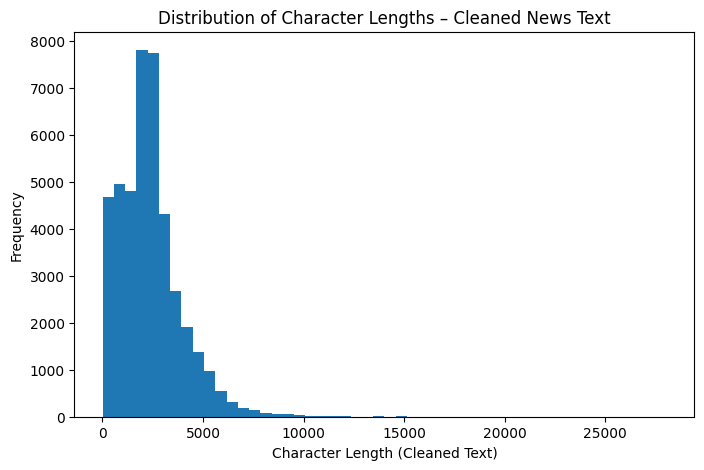

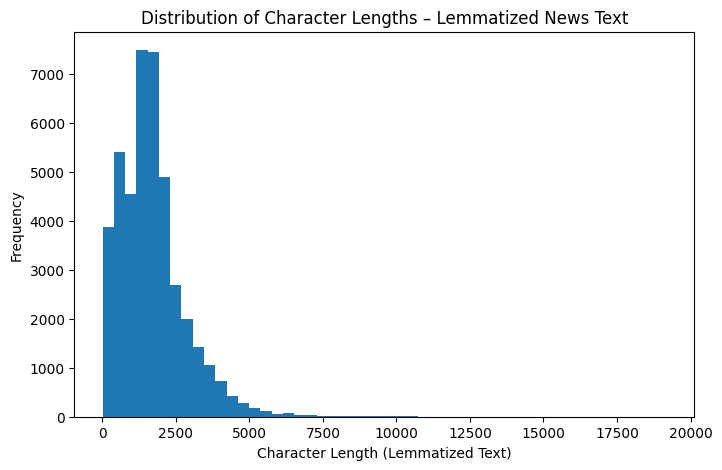

In [68]:
# Create a histogram plot to visualise character lengths
plt.figure(figsize=(8, 5))
plt.hist(df_clean["clean_text_length"], bins=50)
plt.xlabel("Character Length (Cleaned Text)")
plt.ylabel("Frequency")
plt.title("Distribution of Character Lengths – Cleaned News Text")
plt.show()

# Add histogram for cleaned news text

# Add histogram for lemmatized news text with POS tags removed
plt.figure(figsize=(8, 5))
plt.hist(df_clean["lemmatized_text_length"], bins=50)
plt.xlabel("Character Length (Lemmatized Text)")
plt.ylabel("Frequency")
plt.title("Distribution of Character Lengths – Lemmatized News Text")
plt.show()


### **4.2** Find and display the top 40 words by frequency among true and fake news in Training data after processing the text  <font color = red>[10 marks]</font> <br>



##### 4.2.1 Find and display the top 40 words by frequency among true news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

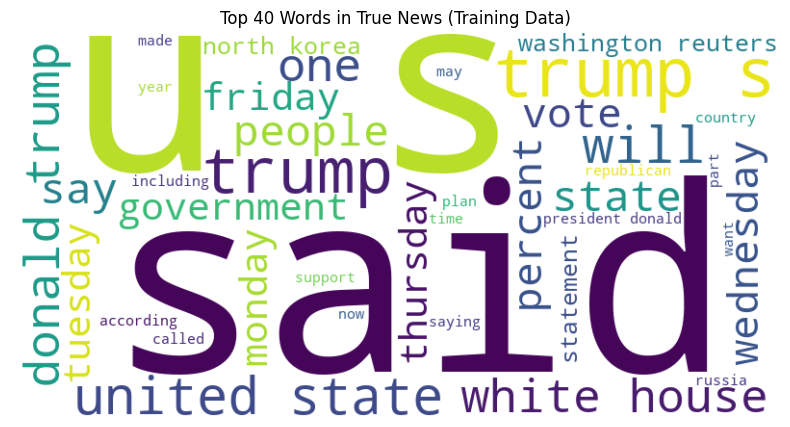

In [71]:
## Use a word cloud find the top 40 words by frequency among true news in the training data after processing the text
import sys
!"{sys.executable}" -m pip install wordcloud

train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

from wordcloud import WordCloud
true_news_text = train_df[train_df["label"] == 1]["text"]

true_news_text_str = " ".join(true_news_text.dropna().astype(str))

# Filter news with label 1 (True News) and convert to it string and handle any non-string values
wordcloud = WordCloud(
    width=800,
    height=400,
    max_words=40,
    background_color="white"
).generate(true_news_text_str)

# Generate word cloud for True News
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Top 40 Words in True News (Training Data)")
plt.show()


##### 4.2.2 Find and display the top 40 words by frequency among fake news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

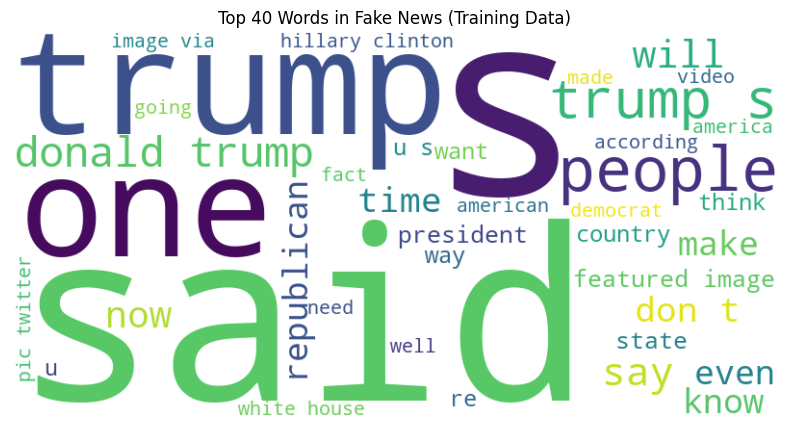

In [73]:
## Use a word cloud find the top 40 words by frequency among fake news in the training data after processing the text
fake_news_text = train_df[train_df["label"] == 0]["text"]
fake_news_text_str = " ".join(fake_news_text.dropna().astype(str))



# Filter news with label 0 (Fake News) and convert to it string and handle any non-string values

# Generate word cloud for Fake News
wordcloud_fake = WordCloud(
    width=800,
    height=400,
    max_words=40,
    background_color="white"
).generate(fake_news_text_str)

# Plot word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_fake, interpolation="bilinear")
plt.axis("off")
plt.title("Top 40 Words in Fake News (Training Data)")
plt.show()



### **4.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  <font color = red>[20 marks]</font> <br>




##### 4.3.1 Write a function to get the specified top n-grams  <font color = red>[4 marks]</font> <br>



In [76]:
# Write a function to get the specified top n-grams
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def get_top_ngrams(corpus, ngram_range=(1, 1), top_n=20):
    """
    Returns a DataFrame of top n-grams by frequency.

    Parameters:
    corpus       : iterable of strings (e.g., text column)
    ngram_range  : tuple (n, n) for n-grams (e.g., (1,1), (2,2))
    top_n        : number of top n-grams to return
    """
    # Vectorize text
    vectorizer = CountVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(corpus)
    
    # Sum word counts
    counts = X.sum(axis=0)
    
    # Map n-grams to counts
    ngram_freq = [
        (ngram, counts[0, idx])
        for ngram, idx in vectorizer.vocabulary_.items()
    ]
    
    # Create DataFrame
    ngram_df = pd.DataFrame(ngram_freq, columns=["ngram", "frequency"])
    
    # Sort and return top n
    return ngram_df.sort_values(by="frequency", ascending=False).head(top_n)

get_top_ngrams(train_df["text"], ngram_range=(1, 1), top_n=20)

,ngram,frequency
2,the,659156
119,to,360698
4,of,287065
27,and,262691
30,in,233060
86,that,156320
20,on,131180
112,for,117952
47,is,109114
122,trump,101132


##### 4.3.2 Handle the NaN values  <font color = red>[1 mark]</font> <br>



In [78]:
# Handle NaN values in the text data
train_df["text"] = train_df["text"].fillna("")

df_clean["clean_text"] = df_clean["clean_text"].fillna("")

train_df["text"].isna().sum()

0

### For True News




##### 4.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

In [81]:
# Print the top 10 unigrams by frequency in true news and plot the same using a bar graph
# Filter True News from training data
true_text = train_df[train_df["label"] == 1]["text"].fillna("")

# Get top 10 unigrams
top_unigrams_true = get_top_ngrams(
    true_text,
    ngram_range=(1, 1),
    top_n=10
)

top_unigrams_true


,ngram,frequency
35,the,339232
6,to,177715
27,of,146613
37,in,130558
67,and,127735
24,on,78339
23,said,69404
121,that,62060
141,for,58106
14,trump,42619


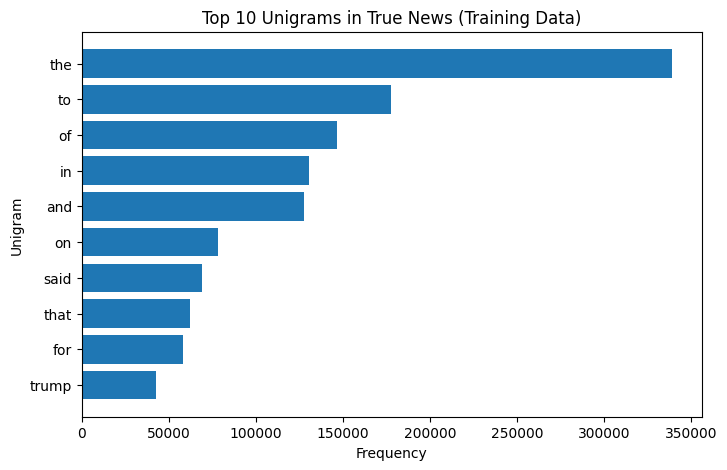

In [82]:
plt.figure(figsize=(8, 5))
plt.barh(
    top_unigrams_true["ngram"],
    top_unigrams_true["frequency"]
)
plt.xlabel("Frequency")
plt.ylabel("Unigram")
plt.title("Top 10 Unigrams in True News (Training Data)")
plt.gca().invert_yaxis()  # highest frequency on top
plt.show()

##### 4.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



In [84]:
# Print the top 10 bigrams by frequency in true news and plot the same using a bar graph
true_text = train_df[train_df["label"] == 1]["text"].fillna("")

# Get top 10 bigrams
top_bigrams_true = get_top_ngrams(
    true_text,
    ngram_range=(2, 2),
    top_n=10
)

top_bigrams_true

,ngram,frequency
85,of the,33826
47,in the,29478
842,to the,15819
115,on the,11627
820,for the,10928
1197,the united,9856
1384,said the,8739
1198,united states,8459
887,and the,8446
766,with the,7797


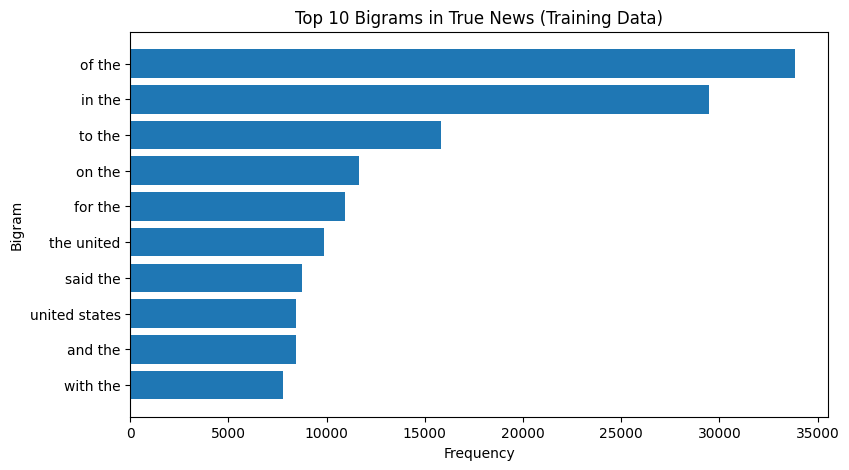

In [85]:
plt.figure(figsize=(9, 5))
plt.barh(
    top_bigrams_true["ngram"],
    top_bigrams_true["frequency"]
)
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Top 10 Bigrams in True News (Training Data)")
plt.gca().invert_yaxis()  # Highest frequency on top
plt.show()

##### 4.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



In [87]:
# Print the top 10 trigrams by frequency in true news and plot the same using a bar graph
true_text = train_df[train_df["label"] == 1]["text"].fillna("")

# Get top 10 trigrams
top_trigrams_true = get_top_ngrams(
    true_text,
    ngram_range=(3, 3),
    top_n=10
)

top_trigrams_true

,ngram,frequency
1290,the united states,8278
12,president donald trump,4144
135,the white house,3781
5368,said in statement,2588
2489,president barack obama,2086
1408,one of the,2051
2485,secretary of state,1623
2830,house of representatives,1605
1843,as well as,1442
1674,said on wednesday,1247


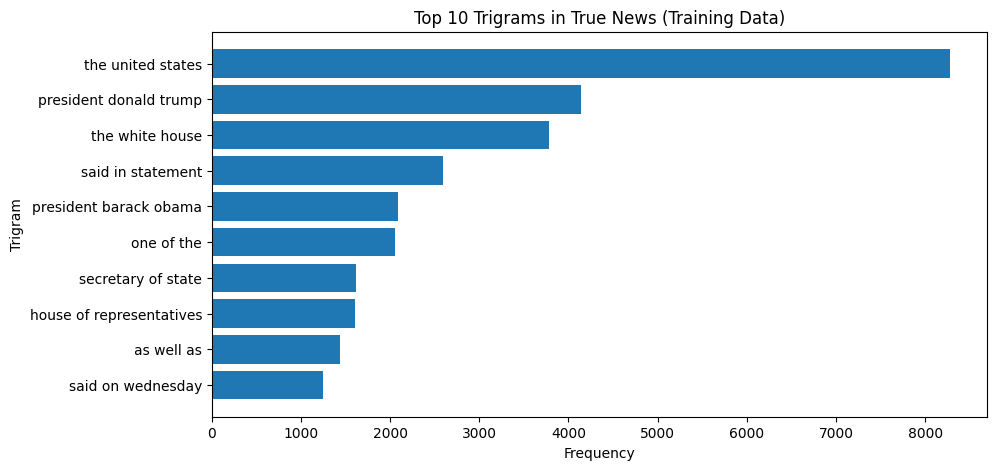

In [88]:
plt.figure(figsize=(10, 5))
plt.barh(
    top_trigrams_true["ngram"],
    top_trigrams_true["frequency"]
)
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.title("Top 10 Trigrams in True News (Training Data)")
plt.gca().invert_yaxis()  # Highest frequency on top
plt.show()

### For Fake News







##### 4.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

In [91]:
# Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph
fake_text = train_df[train_df["label"] == 0]["text"].fillna("")

# Get top 10 unigrams
top_unigrams_fake = get_top_ngrams(
    fake_text,
    ngram_range=(1, 1),
    top_n=10
)

top_unigrams_fake

,ngram,frequency
2,the,319924
119,to,182983
4,of,140452
27,and,134956
30,in,102502
86,that,94260
47,is,69710
112,for,59846
122,trump,58513
87,he,53227


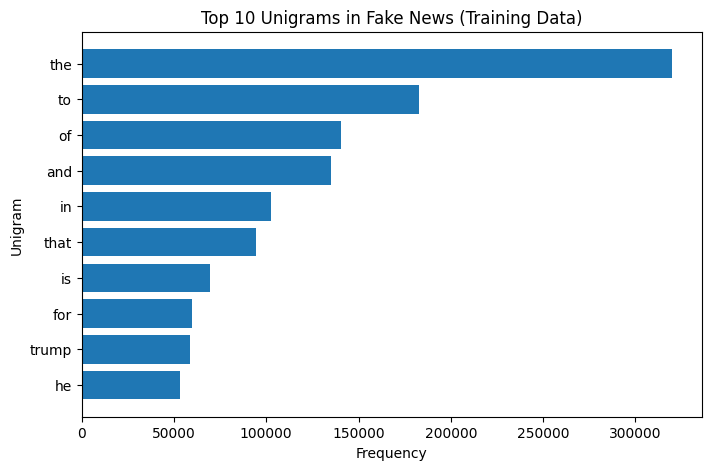

In [92]:
plt.figure(figsize=(8, 5))
plt.barh(
    top_unigrams_fake["ngram"],
    top_unigrams_fake["frequency"]
)
plt.xlabel("Frequency")
plt.ylabel("Unigram")
plt.title("Top 10 Unigrams in Fake News (Training Data)")
plt.gca().invert_yaxis()  # Highest frequency on top
plt.show()

##### 4.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



In [94]:
fake_text = train_df[train_df["label"] == 0]["text"].fillna("")

# Get top 10 bigrams for Fake News
top_bigrams_fake = get_top_ngrams(
    fake_text,
    ngram_range=(2, 2),
    top_n=10
)

# Display the table
top_bigrams_fake

train_df["label"].value_counts()

label
1    14991
0    14985
Name: count, dtype: int64

##### 4.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



In [96]:
# Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph
fake_text = train_df[train_df["label"] == 0]["text"].fillna("")

# Get top 10 trigrams
top_trigrams_fake = get_top_ngrams(
    fake_text,
    ngram_range=(3, 3),
    top_n=10
)

top_trigrams_fake



,ngram,frequency
1562,featured image via,4227
1215,pic twitter com,4220
2002,the united states,3803
2574,the white house,2948
3792,one of the,2572
3390,the fact that,1684
9899,according to the,1428
706,donald trump realdonaldtrump,1141
5021,of the united,1115
1038,out of the,1090


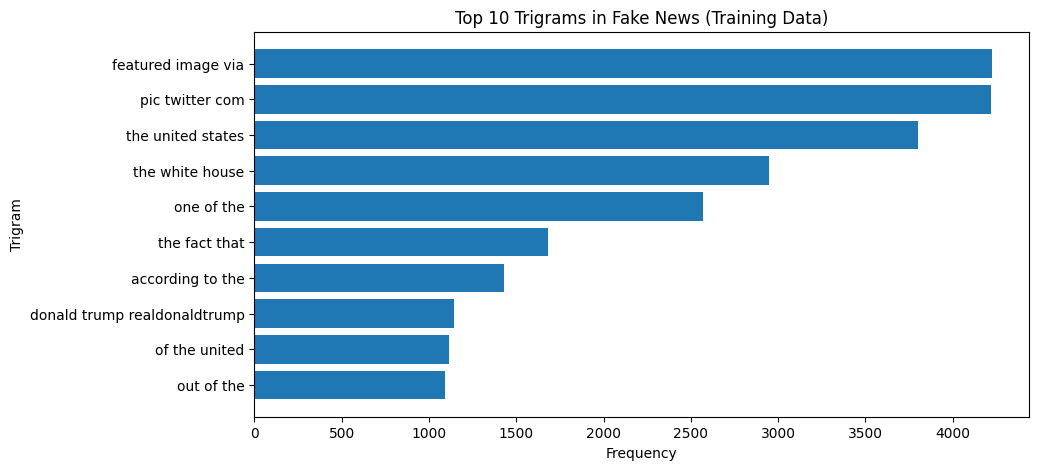

In [97]:
plt.figure(figsize=(10, 5))
plt.barh(
    top_trigrams_fake["ngram"],
    top_trigrams_fake["frequency"]
)
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.title("Top 10 Trigrams in Fake News (Training Data)")
plt.gca().invert_yaxis()  # Highest frequency on top
plt.show()

In [98]:
fake_text = train_df[train_df["label"] == 0]["text"].fillna("")

# Get top 10 trigrams
top_trigrams_fake = get_top_ngrams(
    fake_text,
    ngram_range=(3, 3),
    top_n=10
)

top_trigrams_fake

,ngram,frequency
1562,featured image via,4227
1215,pic twitter com,4220
2002,the united states,3803
2574,the white house,2948
3792,one of the,2572
3390,the fact that,1684
9899,according to the,1428
706,donald trump realdonaldtrump,1141
5021,of the united,1115
1038,out of the,1090


## **5.** Exploratory Data Analysis on Validation Data [Optional]

Perform EDA on validation data to differentiate EDA on training data with EDA on validation data and the tasks are given below:

<ul>
  <li> Visualise the data according to the character length of cleaned news text and lemmatized text with POS tags removed
  <li> Using a word cloud find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **5.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed

##### 5.1.1  Add new columns to calculate the character lengths of the processed data columns

In [102]:
# Add a new column to calculate the character length of cleaned news text

# Add a new column to calculate the character length of lemmatized news text with POS tags removed


##### 5.1.2  Create Histogram to visualise character lengths

Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

In [104]:
# Create a histogram plot to visualise character lengths

# Add histogram for cleaned news text

# Add histogram for lemmatized news text with POS tags removed


### **5.2** Find and display the top 40 words by frequency among true and fake news after processing the text

##### 5.2.1  Find and display the top 40 words by frequency among true news in validation data after processing the text

In [107]:
## Use a word cloud find the top 40 words by frequency among true news after processing the text

# Generate word cloud for True News


##### 5.2.2  Find and display the top 40 words by frequency among fake news in validation data after processing the text

In [109]:
## Use a word cloud find the top 40 words by frequency among fake news after processing the text

# Generate word cloud for Fake News


### **5.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  





##### 5.3.1 Write a function to get the specified top n-grams

In [112]:
## Write a function to get the specified top n-grams


##### 5.3.2 Handle the NaN values

In [114]:
## First handle NaN values in the text data


### For True News



##### 5.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph

In [117]:
## Print the top 10 unigrams by frequency in true news and plot the same using a bar graph


##### 5.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph

In [119]:
## Print the top 10 bigrams by frequency in true news and plot the same using a bar graph


##### 5.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph

In [121]:
## Print the top 10 trigrams by frequency in true news and plot the same using a bar graph


### For Fake News

##### 5.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph

In [124]:
## Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph


##### 5.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph

In [126]:
## Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph


##### 5.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph

In [128]:
## Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph


## **6.** Feature Extraction  <font color = red>[10 marks]</font> <br>

For any ML model to perform classification on textual data, you need to convert it to a vector form. In this assignment, you will use the Word2Vec Vectorizer to create vectors from textual data. Word2Vec model captures the semantic relationship between words.


### **6.1** Initialise Word2Vec model  <font color = red>[2 marks]</font>

In [131]:
import sys
!"{sys.executable}" -m pip install gensim

In [132]:
## Write your code here to initialise the Word2Vec model by downloading "word2vec-google-news-300"
import gensim.downloader as api




In [133]:
# Download & load the pretrained Word2Vec model
word2vec_model = api.load("word2vec-google-news-300")

In [134]:
print(word2vec_model.vector_size)
print(word2vec_model.similarity("news", "report"))

300
0.31236356


### **6.2** Extract vectors for cleaned news data   <font color = red>[8 marks]</font>

In [136]:
## Write your code here to extract the vectors from the Word2Vec model for both training and validation data
import numpy as np
def get_document_vector(text, model):
    """
    Converts a document (string) into a Word2Vec vector
    by averaging word vectors.
    """
    words = text.split()
    word_vectors = [
        model[word] for word in words if word in model.key_to_index
    ]
    
    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(word_vectors, axis=0)

## Extract the target variable for the training data and validation data
# Training data vectors
X_train_w2v = np.vstack(
    X_train.apply(lambda x: get_document_vector(x, word2vec_model))
)

# Validation data vectors
X_val_w2v = np.vstack(
    X_val.apply(lambda x: get_document_vector(x, word2vec_model))
)

y_train_vec = y_train.values
y_val_vec = y_val.values

print("X_train_w2v shape:", X_train_w2v.shape)
print("X_val_w2v shape:", X_val_w2v.shape)

print("y_train shape:", y_train_vec.shape)
print("y_val shape:", y_val_vec.shape)

X_train_w2v shape: (29976, 300)
X_val_w2v shape: (12848, 300)
y_train shape: (29976,)
y_val shape: (12848,)


## **7.** Model Training and Evaluation <font color = red>[45 marks]</font>

You will use a set of supervised models to classify the news into true or fake.

### **7.0** Import models and evaluation metrics

In [247]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

### **7.1** Build Logistic Regression Model  <font color = red>[15 marks]</font>

##### 7.1.1 Create and train logistic regression model on training data  <font color = red>[10 marks]</font>

In [249]:
# Vectorize text
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

# Initialise Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

# Train model
log_reg.fit(X_train_tfidf, y_train)

# Predict on validation data
y_val_pred = log_reg.predict(X_val_tfidf)


##### 7.1.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [254]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.987780199252802
Precision: 0.9861951295176051
Recall   : 0.9894179894179894
F1-score : 0.9878039307076828


In [256]:
# Classification Report
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      6422
           1       0.99      0.99      0.99      6426

    accuracy                           0.99     12848
   macro avg       0.99      0.99      0.99     12848
weighted avg       0.99      0.99      0.99     12848



### **7.2** Build Decision Tree Model <font color = red>[15 marks]</font>

##### 7.2.1 Create and train a decision tree model on training data <font color = red>[10 marks]</font>

In [258]:
from sklearn.tree import DecisionTreeClassifier

# Initialise Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train Decision Tree model on training data
dt_model.fit(X_train_tfidf, y_train)

# Predict on validation data
y_val_pred_dt = dt_model.predict(X_val_tfidf)


##### 7.2.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [260]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_accuracy = accuracy_score(y_val, y_val_pred_dt)
dt_precision = precision_score(y_val, y_val_pred_dt)
dt_recall = recall_score(y_val, y_val_pred_dt)
dt_f1 = f1_score(y_val, y_val_pred_dt)

print("""
Decision Tree Model Performance (Validation Data)
------------------------------------------------
Accuracy : {:.4f}
Precision: {:.4f}
Recall   : {:.4f}
F1-score : {:.4f}
""".format(dt_accuracy, dt_precision, dt_recall, dt_f1))


Decision Tree Model Performance (Validation Data)
------------------------------------------------
Accuracy : 0.9972
Precision: 0.9980
Recall   : 0.9964
F1-score : 0.9972



In [262]:
# Classification Report
print("Decision Tree – Classification Report (Validation Data)\n")
print(classification_report(y_val, y_val_pred_dt))

Decision Tree – Classification Report (Validation Data)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6422
           1       1.00      1.00      1.00      6426

    accuracy                           1.00     12848
   macro avg       1.00      1.00      1.00     12848
weighted avg       1.00      1.00      1.00     12848



### **7.3** Build Random Forest Model <font color = red>[15 marks]</font>


##### 7.3.1 Create and train a random forest model on training data <font color = red>[10 marks]</font>

In [264]:
from sklearn.ensemble import RandomForestClassifier

# Initialise Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train Random Forest model on training data
rf_model.fit(X_train_tfidf, y_train)

# Predict on validation data
y_val_pred_rf = rf_model.predict(X_val_tfidf)


 ##### 7.3.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [266]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
rf_accuracy = accuracy_score(y_val, y_val_pred_rf)
rf_precision = precision_score(y_val, y_val_pred_rf)
rf_recall = recall_score(y_val, y_val_pred_rf)
rf_f1 = f1_score(y_val, y_val_pred_rf)

print("""
Random Forest Model Performance (Validation Data)
------------------------------------------------
Accuracy : {:.4f}
Precision: {:.4f}
Recall   : {:.4f}
F1-score : {:.4f}
""".format(rf_accuracy, rf_precision, rf_recall, rf_f1))


Random Forest Model Performance (Validation Data)
------------------------------------------------
Accuracy : 0.9956
Precision: 0.9953
Recall   : 0.9960
F1-score : 0.9956



In [268]:
# Classification Report
print("Random Forest – Classification Report (Validation Data)\n")
print(
    classification_report(
        y_val,
        y_val_pred_rf,
        target_names=["Fake News", "True News"]
    )
)

Random Forest – Classification Report (Validation Data)

              precision    recall  f1-score   support

   Fake News       1.00      1.00      1.00      6422
   True News       1.00      1.00      1.00      6426

    accuracy                           1.00     12848
   macro avg       1.00      1.00      1.00     12848
weighted avg       1.00      1.00      1.00     12848



## **8.** Conclusion <font color = red>[5 marks]</font>

Summarise your findings by discussing patterns observed in true and fake news and how semantic classification addressed the problem. Highlight the best model chosen, the evaluation metric prioritised for the decision, and assess the approach and its impact.